In [7]:
import numpy as np
import pandas as pd
import os 
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error

# Set up plotting style
plt.rcParams.update({'font.size': 12})
sns.set_style("whitegrid")


In [8]:
# Configuration for paw speed
base_path = "/media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/results"
# eid = "5c0c560e-9e1f-45e9-b66e-e4ee7855be84"  # Updated to the session with paw speed data
eid = "15b69921-d471-4ded-8814-2adad954bcd8"    
# eid = "15763234-d21e-491f-a01b-1238eb96d389" 
# eid = "aad23144-0e52-4eac-80c5-c4ee2decb198"
# eid = "9b528ad0-4599-4a55-9148-96cc1d93fb24"

target = "lightning-pose-right-pawR-speed"  # The paw speed target we decoded
model = "linear"

# Define the two pose models to compare
pose_models = ["MVT_patch_masking_0", "resnet50_0"]



In [9]:
# Store results for each pose model
results = {}

for pose_model in pose_models:
    results_path = f"{base_path}/{eid}/{target}/{pose_model}/{model}/all/{eid}_cv.npy"
    print(f"\n{'='*60}")
    print(f"Loading: {pose_model}")
    print(f"Path: {results_path}")
    
    # Load the data
    data = np.load(results_path, allow_pickle=True).item()
    
    # Extract existing data
    test_y = data['all_test_y']
    test_pred = data['all_test_pred']
    test_metric = data['overall_metric']
    
    
    
    # NEW: Extract ensemble variances and coordinates
    # ens_data = data.get('all_test_ens_vars', {})
    # test_ens_x = ens_data.get('x_ens_var')
    # test_ens_y = ens_data.get('y_ens_var')
    # test_x_coords = ens_data.get('x_coords')
    # test_y_coords = ens_data.get('y_coords')
    
    
    # Flatten for continuous traces
    y_flattened = test_y.flatten()
    pred_flattened = test_pred.flatten()
    
    # # Flatten variances if they exist
    # ens_x_flattened = test_ens_x.flatten() if test_ens_x is not None else None
    # ens_y_flattened = test_ens_y.flatten() if test_ens_y is not None else None

    # Flatten new fields if they exist
    # ens_x_flat = test_ens_x.flatten() if test_ens_x is not None else None
    # ens_y_flat = test_ens_y.flatten() if test_ens_y is not None else None
    # x_coords_flat = test_x_coords.flatten() if test_x_coords is not None else None
    # y_coords_flat = test_y_coords.flatten() if test_y_coords is not None else None
    
    
    # Calculate metrics
    correlation = np.corrcoef(y_flattened, pred_flattened)[0, 1]
    r2 = r2_score(y_flattened, pred_flattened)
    mse = mean_squared_error(y_flattened, pred_flattened)
    
    # Store results
    results[pose_model] = {
        'test_y': test_y,
        'test_pred': test_pred,
        # 'test_ens_x': test_ens_x,        # Added
        # 'test_ens_y': test_ens_y,        # Added
        # 'test_x_coords': test_x_coords,  # Added
        # 'test_y_coords': test_y_coords,  # Added
        'y_flattened': y_flattened,
        'pred_flattened': pred_flattened,
        # 'ens_x_flattened': ens_x_flat,  # Added
        # 'ens_y_flattened': ens_y_flat,  # Added
        # 'x_coords_flattened': x_coords_flat,  # Added
        # 'y_coords_flattened': y_coords_flat,  # Added
        'test_metric': test_metric,
        'r2': r2,
        'mse': mse,
        'correlation': correlation
    }
    
    # print(f"Data shapes: test_y={test_y.shape}, test_pred={test_pred.shape}")
    # if test_ens_x is not None:
    #     print(f"Ensemble variances loaded: x_var={test_ens_x.shape}, y_var={test_ens_y.shape}")
    # else:
    #     print("Ensemble variances not found in this results file.")
    
        
    print(f"R² across timestamps (from file): {test_metric:.3f}")
    print(f"R² (computed): {r2:.3f}")
    print(f"MSE: {mse:.3f}")
    print(f"Correlation: {correlation:.3f}")


Loading: MVT_patch_masking_0
Path: /media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/results/15b69921-d471-4ded-8814-2adad954bcd8/lightning-pose-right-pawR-speed/MVT_patch_masking_0/linear/all/15b69921-d471-4ded-8814-2adad954bcd8_cv.npy
R² across timestamps (from file): 0.067
R² (computed): 0.174
MSE: 0.001
Correlation: 0.417

Loading: resnet50_0
Path: /media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/results/15b69921-d471-4ded-8814-2adad954bcd8/lightning-pose-right-pawR-speed/resnet50_0/linear/all/15b69921-d471-4ded-8814-2adad954bcd8_cv.npy
R² across timestamps (from file): 0.057
R² (computed): 0.130
MSE: 0.002
Correlation: 0.361


In [10]:
# # Store results for each pose model
# results = {}

# for pose_model in pose_models:
#     results_path = f"{base_path}/{eid}/{target}/{pose_model}/{model}/all/{eid}_cv.npy"
#     print(f"\n{'='*60}")
#     print(f"Loading: {pose_model}")
#     print(f"Path: {results_path}")
    
#     # Load the data
#     data = np.load(results_path, allow_pickle=True).item()
    
#     # Extract data
#     test_y = data['all_test_y']
#     test_pred = data['all_test_pred']
#     test_metric = data['overall_metric']
    
#     # Flatten for continuous traces
#     y_flattened = test_y.flatten()
#     pred_flattened = test_pred.flatten()
    
#     # Calculate metrics
#     correlation = np.corrcoef(y_flattened, pred_flattened)[0, 1]
#     r2 = r2_score(y_flattened, pred_flattened)
#     mse = mean_squared_error(y_flattened, pred_flattened)
    
#     # Store results
#     results[pose_model] = {
#         'test_y': test_y,
#         'test_pred': test_pred,
#         'y_flattened': y_flattened,
#         'pred_flattened': pred_flattened,
#         'test_metric': test_metric,
#         'r2': r2,
#         'mse': mse,
#         'correlation': correlation
#     }
    
#     print(f"Data shapes: test_y={test_y.shape}, test_pred={test_pred.shape}")
#     print(f"R² across timestamps (from file): {test_metric:.3f}")
#     print(f"R² (computed): {r2:.3f}")
#     print(f"MSE: {mse:.3f}")
#     print(f"Correlation: {correlation:.3f}")

# # Print comparison summary
# print(f"\n{'='*60}")
# print("COMPARISON SUMMARY")
# print(f"{'='*60}")
# print(f"{'Metric':<25} {f'{pose_models[0]}':>20} {f'{pose_models[1]}':>20}")
# print(f"{'-'*65}")
# print(f"{'R² (timestamps)':<25} {results[pose_models[0]]['test_metric']:>20.3f} {results[pose_models[1]]['test_metric']:>20.3f}")
# print(f"{'R² (computed)':<25} {results[pose_models[0]]['r2']:>20.3f} {results[pose_models[1]]['r2']:>20.3f}")
# print(f"{'Correlation':<25} {results[pose_models[0]]['correlation']:>20.3f} {results[pose_models[1]]['correlation']:>20.3f}")
# print(f"{'MSE':<25} {results[pose_models[0]]['mse']:>20.3f} {results[pose_models[1]]['mse']:>20.3f}")

In [11]:
# Define colors for each pose model
# Darker color for pose model (ground truth), lighter for decoded prediction
colors = {
    'MVT_patch_masking_median': {
        'pose': '#1f77b4',      # Dark blue
        'decoded': '#aec7e8'    # Light blue
    },
    'resnet50_median': {
        'pose': '#d62728',      # Dark red
        'decoded': '#ff9896'    # Light red/pink
    }
}

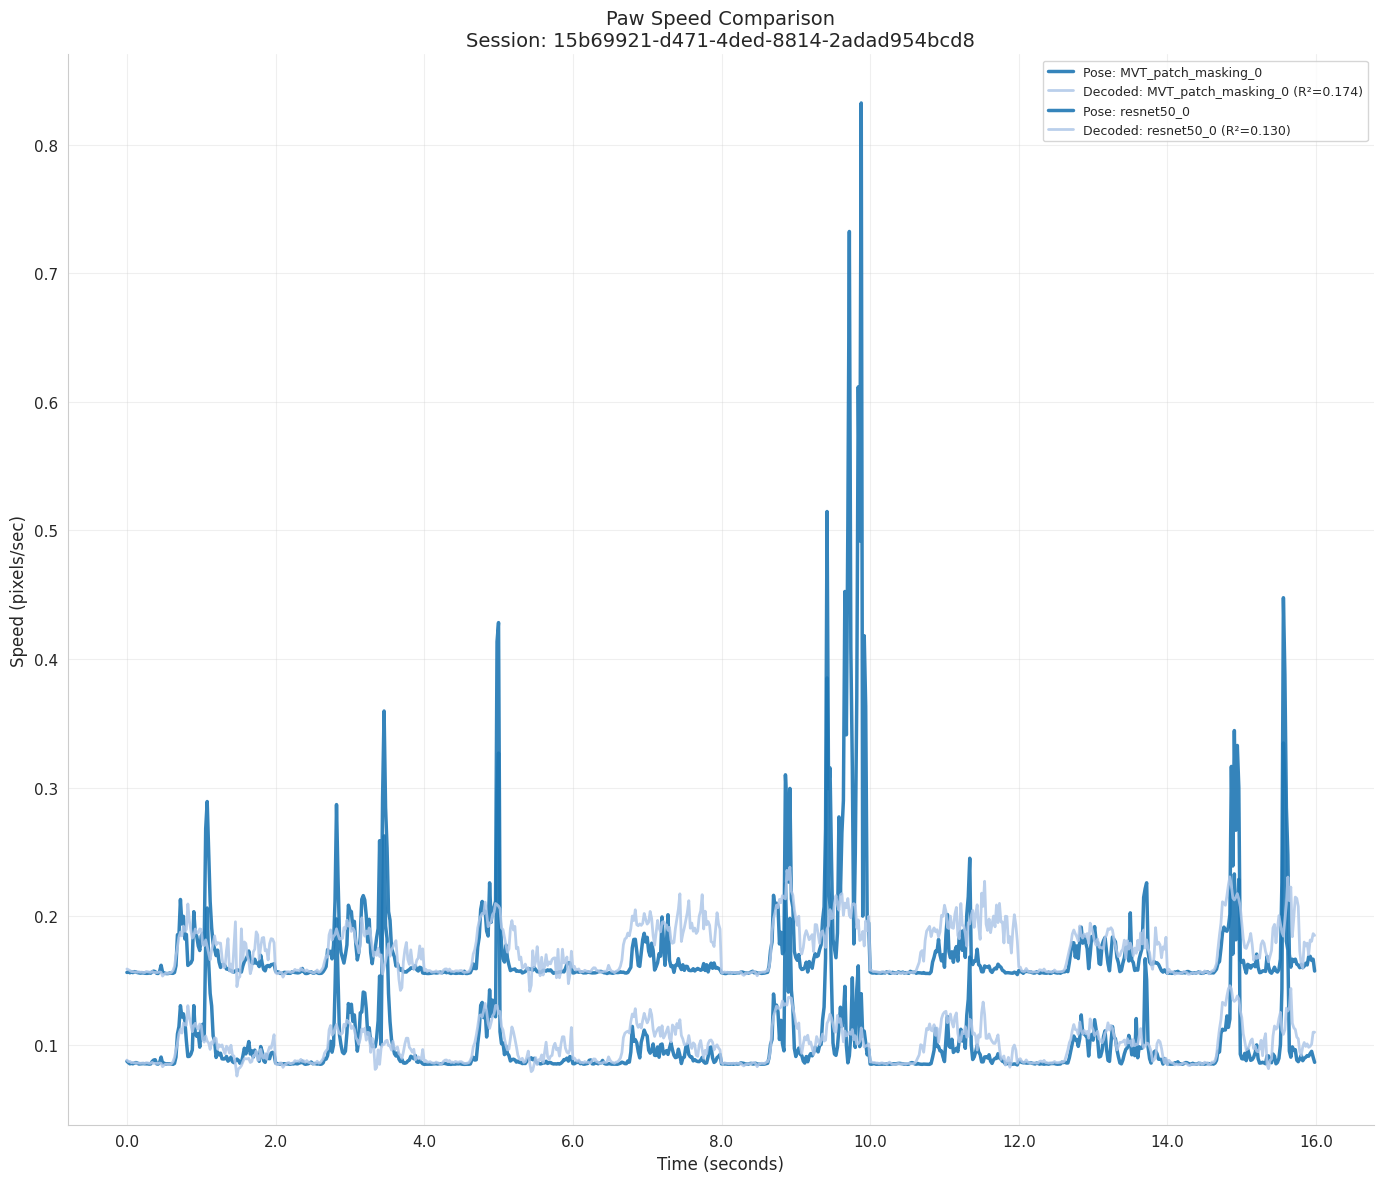

In [14]:
# Plot the continuous paw speed traces and ensemble variances
start_time = 0
end_time = min(800, len(results[pose_models[0]]['y_flattened']))

# Create 1 subplot for now (since we only have speed data)
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# Plot traces for each pose model
for pose_model in pose_models:
    # Check if pose_model exists in colors dictionary
    if pose_model not in colors:
        print(f"Warning: {pose_model} not found in colors dictionary. Using default colors.")
        # Use default colors if pose_model not in colors dict
        pose_color = '#1f77b4'  # Default blue
        decoded_color = '#aec7e8'  # Default light blue
    else:
        pose_color = colors[pose_model]['pose']
        decoded_color = colors[pose_model]['decoded']
    
    # 1. Plot Speed Traces
    y_flat = results[pose_model]['y_flattened']
    pred_flat = results[pose_model]['pred_flattened']
    r2_val = results[pose_model]['r2']
    
    ax.plot(y_flat[start_time:end_time], 
            color=pose_color, 
            linewidth=2.5, 
            label=f"Pose: {pose_model}", 
            alpha=0.9)
    
    ax.plot(pred_flat[start_time:end_time], 
            color=decoded_color, 
            linewidth=2, 
            label=f"Decoded: {pose_model} (R²={r2_val:.3f})", 
            alpha=0.85)
    
    # # 2. Plot X Ensemble Variance (Middle Subplot)
    # if results[pose_model]['ens_x_flattened'] is not None:
    #     ax[1].plot(results[pose_model]['ens_x_flattened'][start_time:end_time], 
    #                color=colors[pose_model]['pose'], 
    #                linewidth=2, 
    #                label=f"{pose_model} X-Var", 
    #                alpha=0.8)

    # # 3. Plot Y Ensemble Variance (Bottom Subplot)
    # if results[pose_model]['ens_y_flattened'] is not None:
    #     ax[2].plot(results[pose_model]['ens_y_flattened'][start_time:end_time], 
    #                color=colors[pose_model]['pose'], 
    #                linewidth=2, 
    #                label=f"{pose_model} Y-Var", 
    #                alpha=0.8)
    # # 4. Plot X Coordinates (Bottom Subplot)
    # if results[pose_model]['x_coords_flattened'] is not None:
    #     ax[3].plot(results[pose_model]['x_coords_flattened'][start_time:end_time], 
    #                color=colors[pose_model]['pose'], 
    #                linewidth=2, 
    #                label=f"{pose_model} X-Coords", 
    #                alpha=0.8)
    # # 5. Plot Y Coordinates (Bottom Subplot)
    # if results[pose_model]['y_coords_flattened'] is not None:
    #     ax[4].plot(results[pose_model]['y_coords_flattened'][start_time:end_time], 
    #                color=colors[pose_model]['pose'], 
    #                linewidth=2, 
    #                label=f"{pose_model} Y-Coords", 
    #                alpha=0.8)

# Formatting for the subplot
ax.set_ylabel("Speed (pixels/sec)", fontsize=12)
ax.set_title(f"Paw Speed Comparison\nSession: {eid}", fontsize=14)
ax.set_xlabel("Time (seconds)", fontsize=12)

ax.legend(fontsize=9, loc='upper right', framealpha=0.8)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=11)

# Convert x-axis to time in seconds
xticks = [0, 100, 200, 300, 400, 500, 600, 700, 800]
xticklabels = [f"{x * 0.02:.1f}" for x in xticks]
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)

plt.tight_layout()
plt.show()

Zoomed In version

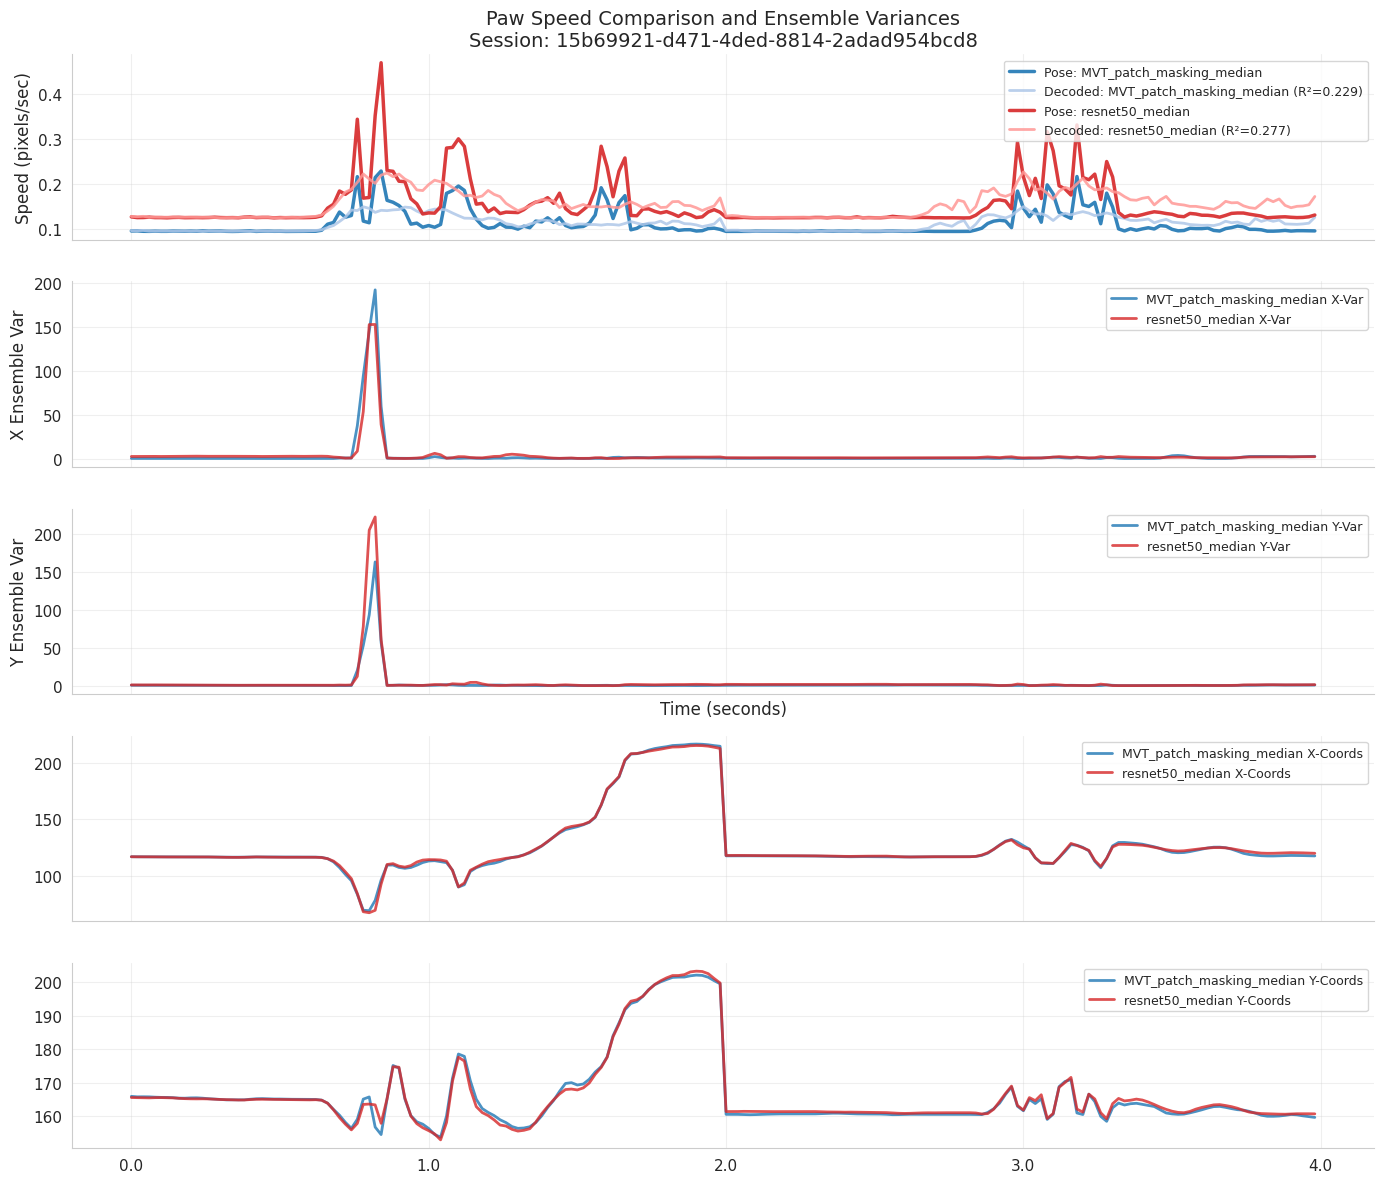

In [17]:
# Plot the continuous paw speed traces and ensemble variances
start_time = 400
end_point = 600
end_time = min(end_point, len(results[pose_models[0]]['y_flattened']))

# Create 3 subplots: Speed, X-Variance, Y-Variance
fig, ax = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

# Plot traces for each pose model
for pose_model in pose_models:
    # 1. Plot Speed Traces (Top Subplot)
    y_flat = results[pose_model]['y_flattened']
    pred_flat = results[pose_model]['pred_flattened']
    r2_val = results[pose_model]['r2']
    
    ax[0].plot(y_flat[start_time:end_time], 
               color=colors[pose_model]['pose'], 
               linewidth=2.5, 
               label=f"Pose: {pose_model}", 
               alpha=0.9)
    
    ax[0].plot(pred_flat[start_time:end_time], 
               color=colors[pose_model]['decoded'], 
               linewidth=2, 
               label=f"Decoded: {pose_model} (R²={r2_val:.3f})", 
               alpha=0.85)
    
    # 2. Plot X Ensemble Variance (Middle Subplot)
    if results[pose_model]['ens_x_flattened'] is not None:
        ax[1].plot(results[pose_model]['ens_x_flattened'][start_time:end_time], 
                   color=colors[pose_model]['pose'], 
                   linewidth=2, 
                   label=f"{pose_model} X-Var", 
                   alpha=0.8)

    # 3. Plot Y Ensemble Variance (Bottom Subplot)
    if results[pose_model]['ens_y_flattened'] is not None:
        ax[2].plot(results[pose_model]['ens_y_flattened'][start_time:end_time], 
                   color=colors[pose_model]['pose'], 
                   linewidth=2, 
                   label=f"{pose_model} Y-Var", 
                   alpha=0.8)
    # 4. Plot X Coordinates (Bottom Subplot)
    if results[pose_model]['x_coords_flattened'] is not None:
        ax[3].plot(results[pose_model]['x_coords_flattened'][start_time:end_time], 
                   color=colors[pose_model]['pose'], 
                   linewidth=2, 
                   label=f"{pose_model} X-Coords", 
                   alpha=0.8)
    # 5. Plot Y Coordinates (Bottom Subplot)
    if results[pose_model]['y_coords_flattened'] is not None:
        ax[4].plot(results[pose_model]['y_coords_flattened'][start_time:end_time], 
                   color=colors[pose_model]['pose'], 
                   linewidth=2, 
                   label=f"{pose_model} Y-Coords", 
                   alpha=0.8)

# Formatting for all subplots
ax[0].set_ylabel("Speed (pixels/sec)", fontsize=12)
ax[0].set_title(f"Paw Speed Comparison and Ensemble Variances\nSession: {eid}", fontsize=14)
ax[1].set_ylabel("X Ensemble Var", fontsize=12)
ax[2].set_ylabel("Y Ensemble Var", fontsize=12)
ax[2].set_xlabel("Time (seconds)", fontsize=12)

for a in ax:
    a.legend(fontsize=9, loc='upper right', framealpha=0.8)
    a.grid(True, alpha=0.3)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.tick_params(axis='both', labelsize=11)

# Convert x-axis to time in seconds (aligned across all)
xticks = [0, 50, 100, 150, 200]
xticklabels = [f"{x * 0.02:.1f}" for x in xticks]
ax[2].set_xticks(xticks)
ax[2].set_xticklabels(xticklabels)

plt.tight_layout()
plt.show()

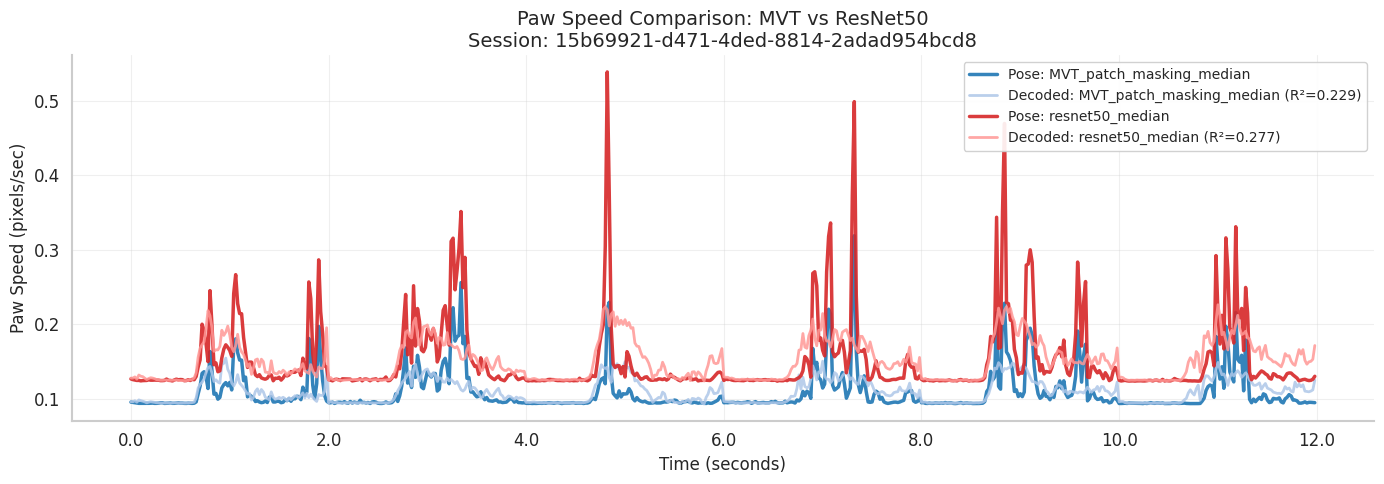

In [ ]:
# # Plot the continuous paw speed traces
# start_time = 0
# end_time = min(600, len(results[pose_models[0]]['y_flattened']))

# fig, ax = plt.subplots(1, 1, figsize=(14, 5))

# # Plot traces for each pose model
# for pose_model in pose_models:
#     y_flat = results[pose_model]['y_flattened']
#     pred_flat = results[pose_model]['pred_flattened']
#     r2_val = results[pose_model]['r2']
    
#     # Pose model trace (ground truth) - darker, thicker
#     ax.plot(y_flat[start_time:end_time], 
#             color=colors[pose_model]['pose'], 
#             linewidth=2.5, 
#             label=f"Pose: {pose_model}", 
#             alpha=0.9)
    
#     # Decoded prediction - lighter, slightly thinner
#     ax.plot(pred_flat[start_time:end_time], 
#             color=colors[pose_model]['decoded'], 
#             linewidth=2, 
#             label=f"Decoded: {pose_model} (R²={r2_val:.3f})", 
#             alpha=0.85,
#             linestyle='-')

# # Formatting
# ax.set_ylabel("Paw Speed (pixels/sec)", fontsize=12)
# ax.set_xlabel("Time (seconds)", fontsize=12)
# ax.set_title(f"Paw Speed Comparison: MVT vs ResNet50\nSession: {eid}", fontsize=14)
# ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
# ax.grid(True, alpha=0.3)

# # Remove top and right spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_linewidth(1.5)
# ax.spines['bottom'].set_linewidth(1.5)
# ax.tick_params(axis='both', width=1.5, length=5, labelsize=12)

# # Convert x-axis to time in seconds
# xticks = [0, 100, 200, 300, 400, 500, 600]
# xticklabels = [f"{x * 0.02:.1f}" for x in xticks]
# ax.set_xticks(xticks)
# ax.set_xticklabels(xticklabels)

# plt.tight_layout()
# # plt.savefig('paw_speed_comparison.png', dpi=400, bbox_inches='tight')
# plt.show()

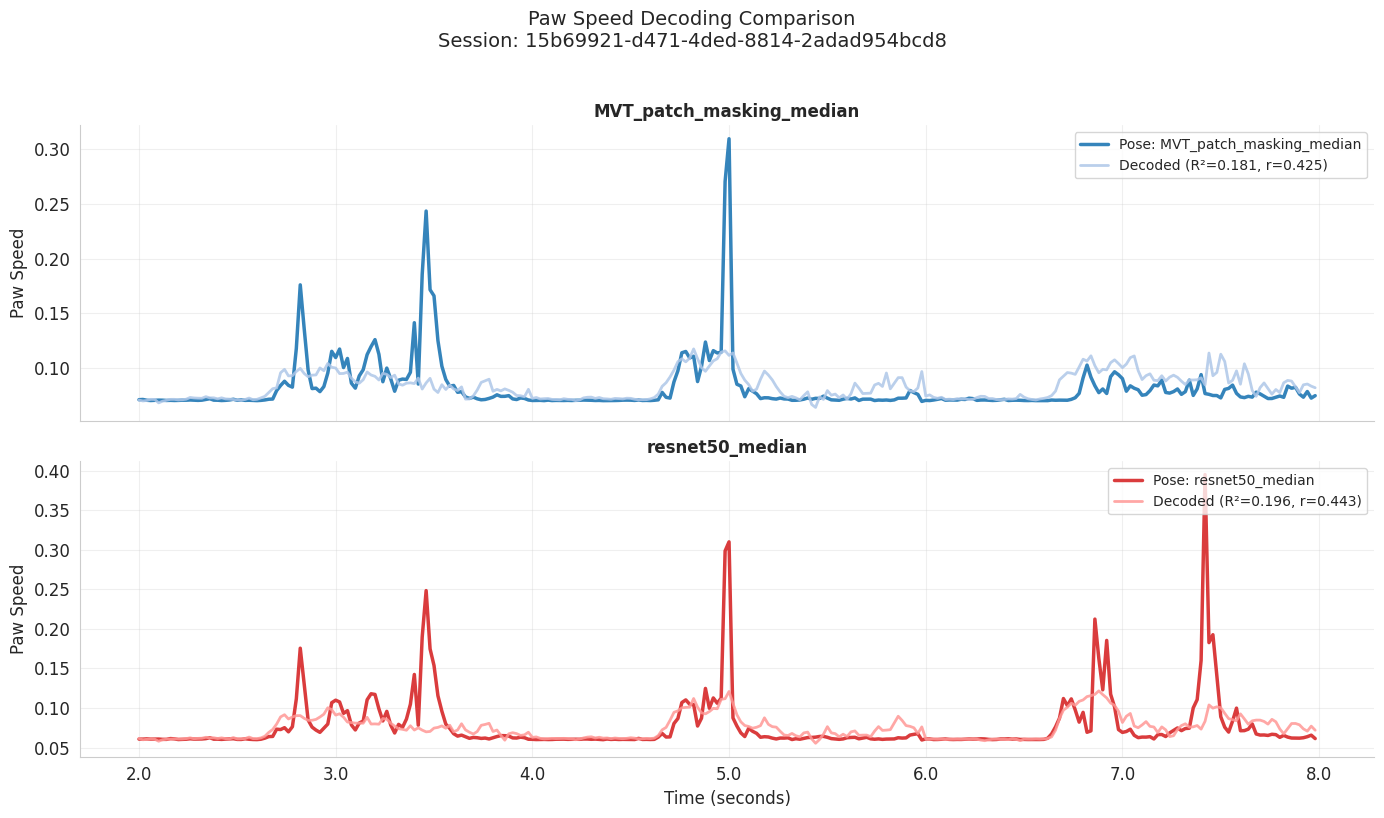

In [16]:
# Alternative: Zoomed-in view for better visibility of differences
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Shorter time window to see details
zoom_start = 100
zoom_end = 400

for idx, pose_model in enumerate(pose_models):
    ax = axes[idx]
    y_flat = results[pose_model]['y_flattened']
    pred_flat = results[pose_model]['pred_flattened']
    r2_val = results[pose_model]['r2']
    corr_val = results[pose_model]['correlation']
    
    # Pose model trace (ground truth)
    ax.plot(range(zoom_start, zoom_end), 
            y_flat[zoom_start:zoom_end], 
            color=colors[pose_model]['pose'], 
            linewidth=2.5, 
            label=f"Pose: {pose_model}", 
            alpha=0.9)
    
    # Decoded prediction
    ax.plot(range(zoom_start, zoom_end), 
            pred_flat[zoom_start:zoom_end], 
            color=colors[pose_model]['decoded'], 
            linewidth=2, 
            label=f"Decoded (R²={r2_val:.3f}, r={corr_val:.3f})", 
            alpha=0.85)
    
    ax.set_ylabel("Paw Speed", fontsize=12)
    ax.set_title(f"{pose_model}", fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[1].set_xlabel("Time (seconds)", fontsize=12)

# Convert x-axis to time in seconds
xticks = [100, 150, 200, 250, 300, 350, 400]
xticklabels = [f"{x * 0.02:.1f}" for x in xticks]
axes[1].set_xticks(xticks)
axes[1].set_xticklabels(xticklabels)

plt.suptitle(f"Paw Speed Decoding Comparison\nSession: {eid}", fontsize=14, y=1.02)
plt.tight_layout()
# plt.savefig('paw_speed_comparison_subplots.png', dpi=400, bbox_inches='tight')
plt.show()

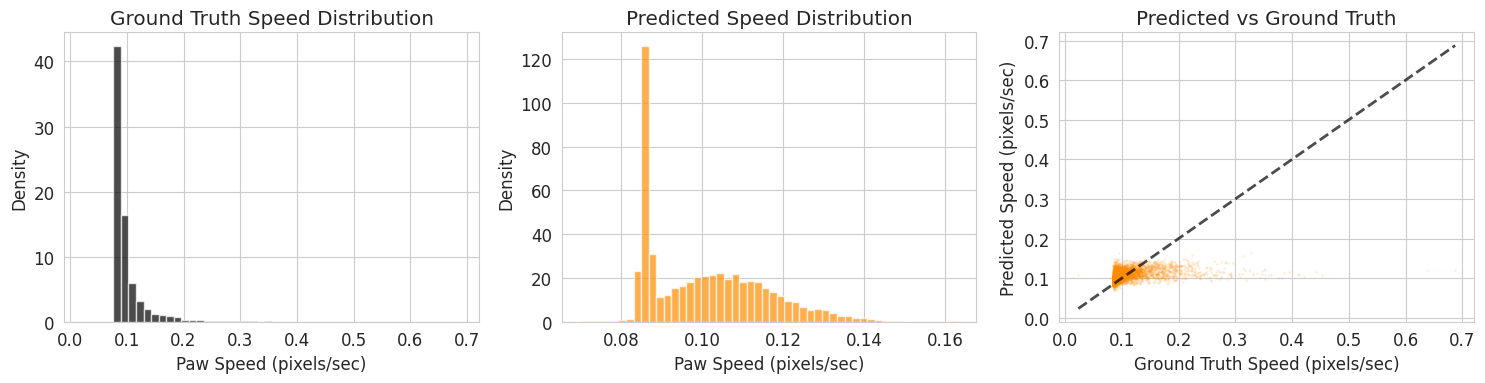

In [21]:
# Additional analysis: Plot distribution of speeds
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of ground truth speeds
axes[0].hist(y_flattened, bins=50, alpha=0.7, color='black', density=True)
axes[0].set_title('Ground Truth Speed Distribution')
axes[0].set_xlabel('Paw Speed (pixels/sec)')
axes[0].set_ylabel('Density')

# Distribution of predicted speeds
axes[1].hist(pred_flattened, bins=50, alpha=0.7, color='darkorange', density=True)
axes[1].set_title('Predicted Speed Distribution')
axes[1].set_xlabel('Paw Speed (pixels/sec)')
axes[1].set_ylabel('Density')

# Scatter plot: predicted vs ground truth
axes[2].scatter(y_flattened, pred_flattened, alpha=0.1, s=1, color='darkorange')
axes[2].plot([y_flattened.min(), y_flattened.max()], [y_flattened.min(), y_flattened.max()], 
             'k--', linewidth=2, alpha=0.7)
axes[2].set_title('Predicted vs Ground Truth')
axes[2].set_xlabel('Ground Truth Speed (pixels/sec)')
axes[2].set_ylabel('Predicted Speed (pixels/sec)')

plt.tight_layout()
plt.savefig('paw_speed_analysis.png', dpi=400, bbox_inches='tight')
plt.show()

# Running Analysis for all seeds 

In [10]:
eids = [
    "5c0c560e-9e1f-45e9-b66e-e4ee7855be84",
    "15b69921-d471-4ded-8814-2adad954bcd8",
    "15763234-d21e-491f-a01b-1238eb96d389",
    "aad23144-0e52-4eac-80c5-c4ee2decb198",
    "9b528ad0-4599-4a55-9148-96cc1d93fb24",
]

In [12]:
# Store results for all sessions and pose models
all_results = []

for eid in eids:
    print(f"\n{'='*60}")
    print(f"Session: {eid}")
    print(f"{'='*60}")
    
    for pose_model in pose_models:
        results_path = f"{base_path}/{eid}/{target}/{pose_model}/{model}/all/{eid}_cv.npy"
        
        try:
            # Load the data
            data = np.load(results_path, allow_pickle=True).item()
            
            # Extract data
            test_y = data['all_test_y']
            test_pred = data['all_test_pred']
            test_metric = data['overall_metric']
            
            # Flatten for continuous traces
            y_flattened = test_y.flatten()
            pred_flattened = test_pred.flatten()
            
            # Calculate metrics
            correlation = np.corrcoef(y_flattened, pred_flattened)[0, 1]
            r2 = r2_score(y_flattened, pred_flattened)
            mse = mean_squared_error(y_flattened, pred_flattened)
            
            # Store results
            all_results.append({
                'eid': eid,
                'eid_short': eid[:8],  # Short version for plotting
                'pose_model': pose_model,
                'test_metric': test_metric,
                'r2': r2,
                'mse': mse,
                'correlation': correlation,
                'n_trials': test_y.shape[0]
            })
            
            print(f"  {pose_model}: R²={r2:.3f}, Corr={correlation:.3f}")
            
        except FileNotFoundError:
            print(f"  {pose_model}: FILE NOT FOUND")
        except Exception as e:
            print(f"  {pose_model}: ERROR - {e}")

# Convert to DataFrame for easier analysis
df = pd.DataFrame(all_results)
print(f"\n{'='*60}")
print("RESULTS DATAFRAME")
print(f"{'='*60}")
print(df)


Session: 5c0c560e-9e1f-45e9-b66e-e4ee7855be84
  MVT_patch_masking_0: R²=0.319, Corr=0.565
  resnet50_0: R²=0.264, Corr=0.514

Session: 15b69921-d471-4ded-8814-2adad954bcd8
  MVT_patch_masking_0: R²=0.174, Corr=0.417
  resnet50_0: R²=0.130, Corr=0.361

Session: 15763234-d21e-491f-a01b-1238eb96d389
  MVT_patch_masking_0: R²=0.120, Corr=0.348
  resnet50_0: R²=0.231, Corr=0.484

Session: aad23144-0e52-4eac-80c5-c4ee2decb198
  MVT_patch_masking_0: R²=0.064, Corr=0.252
  resnet50_0: R²=0.033, Corr=0.185

Session: 9b528ad0-4599-4a55-9148-96cc1d93fb24
  MVT_patch_masking_0: R²=0.174, Corr=0.418
  resnet50_0: R²=0.253, Corr=0.505

RESULTS DATAFRAME
                                    eid eid_short           pose_model  \
0  5c0c560e-9e1f-45e9-b66e-e4ee7855be84  5c0c560e  MVT_patch_masking_0   
1  5c0c560e-9e1f-45e9-b66e-e4ee7855be84  5c0c560e           resnet50_0   
2  15b69921-d471-4ded-8814-2adad954bcd8  15b69921  MVT_patch_masking_0   
3  15b69921-d471-4ded-8814-2adad954bcd8  15b69921      

In [13]:
# Summary statistics per pose model
print(f"\n{'='*60}")
print("SUMMARY STATISTICS")
print(f"{'='*60}")
summary = df.groupby('pose_model').agg({
    'r2': ['mean', 'std', 'min', 'max'],
    'correlation': ['mean', 'std'],
    'mse': ['mean', 'std']
}).round(3)
print(summary)

# Pivot table for easy comparison
print(f"\n{'='*60}")
print("R² BY SESSION AND MODEL")
print(f"{'='*60}")
pivot = df.pivot(index='eid_short', columns='pose_model', values='r2').round(3)
print(pivot)


SUMMARY STATISTICS
                        r2                      correlation           mse  \
                      mean    std    min    max        mean    std   mean   
pose_model                                                                  
MVT_patch_masking_0  0.170  0.095  0.064  0.319        0.40  0.115  0.001   
resnet50_0           0.182  0.099  0.033  0.264        0.41  0.140  0.001   

                            
                       std  
pose_model                  
MVT_patch_masking_0  0.001  
resnet50_0           0.001  

R² BY SESSION AND MODEL
pose_model  MVT_patch_masking_0  resnet50_0
eid_short                                  
15763234                  0.120       0.231
15b69921                  0.174       0.130
5c0c560e                  0.319       0.264
9b528ad0                  0.174       0.253
aad23144                  0.064       0.033


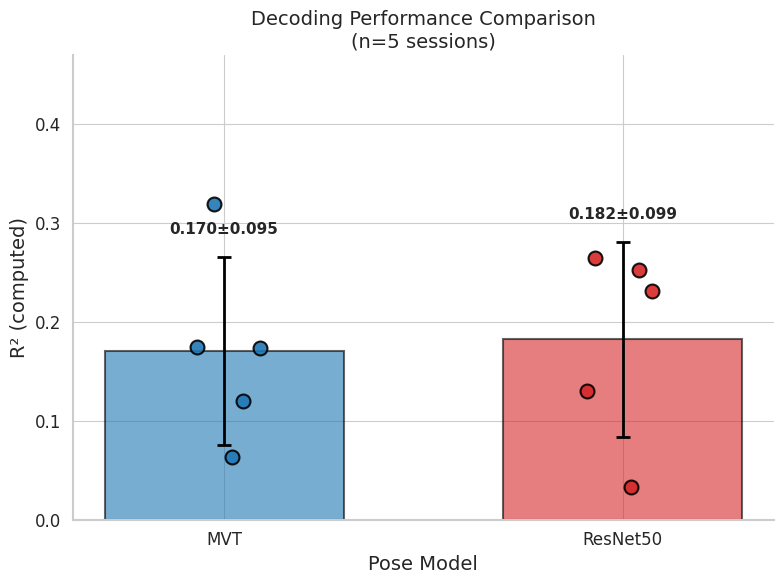

In [14]:
# Bar plot with individual session dots
fig, ax = plt.subplots(figsize=(8, 6))

# Colors matching the previous plots
colors = {
    'MVT_patch_masking_0': '#1f77b4',  # Blue
    'resnet50_0': '#d62728'             # Red
}

# Calculate mean R² for each pose model
mean_r2 = df.groupby('pose_model')['r2'].mean()
std_r2 = df.groupby('pose_model')['r2'].std()

# Bar positions
x_positions = np.arange(len(pose_models))
bar_width = 0.6

# Plot bars (mean values)
bars = ax.bar(x_positions, 
              [mean_r2[pm] for pm in pose_models],
              width=bar_width,
              color=[colors[pm] for pm in pose_models],
              alpha=0.6,
              edgecolor='black',
              linewidth=1.5,
              label='Mean R²')

# Add error bars (standard deviation)
ax.errorbar(x_positions, 
            [mean_r2[pm] for pm in pose_models],
            yerr=[std_r2[pm] for pm in pose_models],
            fmt='none',
            color='black',
            capsize=5,
            capthick=2,
            linewidth=2)

# Add individual session dots
np.random.seed(42)  # For reproducible jitter
for i, pose_model in enumerate(pose_models):
    session_r2 = df[df['pose_model'] == pose_model]['r2'].values
    # Add small jitter for visibility
    jitter = np.random.uniform(-0.1, 0.1, size=len(session_r2))
    ax.scatter(np.full_like(session_r2, i) + jitter, 
               session_r2,
               color=colors[pose_model],
               edgecolor='black',
               s=100,
               zorder=5,
               linewidth=1.5,
               alpha=0.9)

# Formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(['MVT', 'ResNet50'], fontsize=14)
ax.set_ylabel('R² (computed)', fontsize=14)
ax.set_xlabel('Pose Model', fontsize=14)
ax.set_title(f'Decoding Performance Comparison\n(n={len(eids)} sessions)', fontsize=14)

# Add mean values as text on bars
for i, pm in enumerate(pose_models):
    ax.text(i, mean_r2[pm] + std_r2[pm] + 0.02, 
            f'{mean_r2[pm]:.3f}±{std_r2[pm]:.3f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', width=1.5, length=5, labelsize=12)

# Set y-axis to start from 0
ax.set_ylim(0, max(df['r2']) + 0.15)

plt.tight_layout()
# plt.savefig('r2_comparison_histogram.png', dpi=400, bbox_inches='tight')
plt.show()